### Banco de Dados II - Arthur Monteiro C. Pereira - UFRJ Analytica

#### Análise do mercado: **Will Donald Trump win the 2024 US Presidential Election?** (market_id: 253591)

#### Objetivo

Investigar o mercado de id 253591 (*"Will Donald Trump win the 2024 US Presidential Election?"*) no Polymarket para entender como poucas carteiras concentraram apostas gigantescas a favor de Trump antes da eleição de 2024 nos EUA.

A análise se inspira no [caso do trader francês "Théo"](https://finance.yahoo.com/news/polymarket-whale-actually-made-85-050139914.html). A partir de outubro de 2024, ele usou diversas contas para apostar grandes volumes na vitória do candidato. Tal movimentação atípica rendeu a ele um lucro estimado de mais de  US$ 85 milhões.

#### Pergunta de Pesquisa

É possível, a partir dos dados de negociação do mercado 253591, identificar um padrão de acumulação atípica de posição, concentrado em poucos endereços, com volume muito acima da média, iniciado antes das principais datas de reviravolta da campanha, compatível com o comportamento relatado na imprensa sobre o "Trump Whale"?

#### Hipótese Inicial

Esperamos identificar um pequeno número de endereços com volume de negociação ordens de magnitude maior que o do trader mediano, concentrados no lado "Trump vence" e ativos por volta de outubro de 2024. Reconhecemos, no entanto, que os dados on-chain sozinhos (sem os apelidos usados na Polymarket) podem não ser suficientes para confirmar que se trata do mesmo grupo relatado pela imprensa, apenas indicar um padrão estatisticamente compatível.

#### Exploração Inicial

#### Query A - série diária do mercado

Série diária agregada (view `v_market_daily`, tabela mart de baixo custo), usada para observar o formato do volume negociado ao longo de toda a vida do mercado e localizar o período de maior atividade.

```sql
-- Query A: serie diaria do mercado escolhido (volume, trades, preco medio)
select trade_date, daily_trade_count, daily_usd_volume, avg_trade_price, rolling_7d_avg_volume
from `even-continuity-441808-j0.polymarket_mart.v_market_daily`
where market_id = '253591'
order by trade_date;
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dados/mercado_eleicao_diario.csv")
df["trade_date"] = pd.to_datetime(df["trade_date"])
df.head()

,trade_date,daily_trade_count,daily_usd_volume,avg_trade_price,rolling_7d_avg_volume
0,2024-01-05,80,19854.58,0.494750,19854.580000
1,2024-01-06,58,27677.28,0.481379,23765.930000
2,2024-01-07,114,328853.26,0.475000,125461.706667
3,2024-01-08,38,41402.92,0.514211,104447.010000
4,2024-01-09,19,2275.68,0.537368,84012.744000


trade_date: o dia.
daily_trade_count: quantos trades rolaram nesse dia.
daily_usd_volume: quanto dinheiro passou no total nesse dia.
avg_trade_price: o preço médio do token no dia, aumenta ou diminui conforme a probabilidade do Trump ganhar.
rolling_7d_avg_volume: a média do volume dos últimos 7 dias, só pra comparação.

A análise foca no período diário de 05/01/2024 a 06/11/2024 (307 dias), recorte que soma aproximadamente US$ 818 milhões negociados.

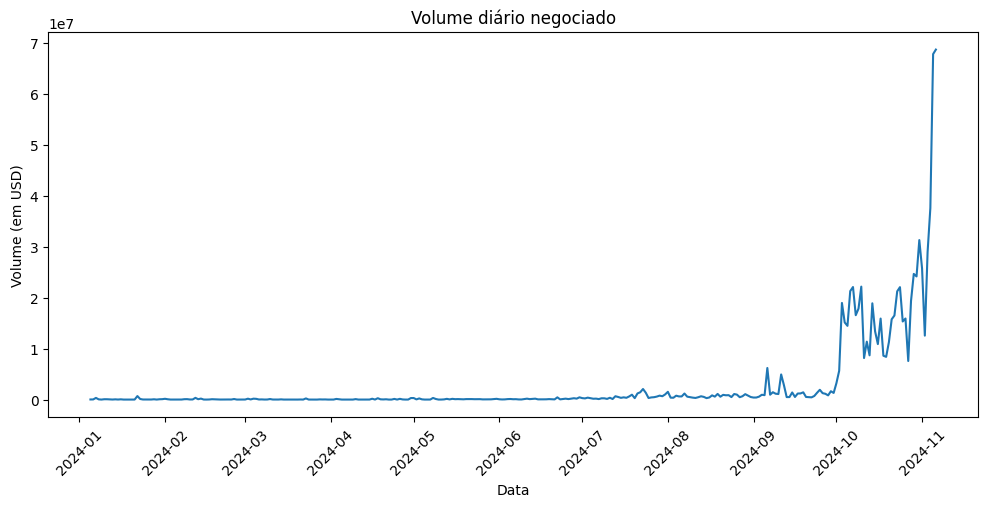

In [2]:
plt.figure(figsize=(12,5))
plt.plot(df["trade_date"], df["daily_usd_volume"])
plt.title("Volume diário negociado")
plt.xlabel("Data")
plt.ylabel("Volume (em USD)")
plt.xticks(rotation=45)
plt.show()

O volume permanece baixo durante praticamente todo o primeiro semestre de 2024, com crescimento perceptível a partir de outubro e um pico acentuado nos dois últimos dias antes/durante a apuração (05 e 06/11). Esse formato motivou o recorte de outubro-novembro como janela de interesse para o restante da nossa análise.

### Query B - endereços com maior volume no mercado

Agregação por endereço na tabela `daily_user_stats`, para localizar os maiores traders do mercado.

```sql
-- top 20 enderecos por volume total negociado no mercado
select
  address,
  min(trade_date) as first_trade_date,
  max(trade_date) as last_trade_date,
  sum(total_usd_volume) as total_usd_volume,
  sum(trade_count) as total_trades
from `even-continuity-441808-j0.polymarket_mart.daily_user_stats`
where market_id = '253591'
  and trade_date between '2024-01-01' and '2024-11-10'
group by address
order by total_usd_volume desc
limit 20;
```

In [3]:
top_enderecos = pd.read_csv("dados/top_enderecos.csv")
top_enderecos.head(20)

,address,first_trade_date,last_trade_date,total_usd_volume,total_trades
0,0x5bffcf561bcae83af680ad600cb99f1184d6ffbe,2024-06-13,2024-11-06,62004036.95,96119
1,0x971f91a412236cc942a6f4485d3d88aa8dcb5929,2024-10-30,2024-11-06,39950009.09,123637
2,0xa1d75a199ef084ee3ec9ae60dc986b439fe6e17e,2024-08-14,2024-10-20,39010556.06,60683
3,0xf8ba34bf0e95d952d05b578bfbc0833f9242a286,2024-07-11,2024-11-06,32159689.02,140031
4,0xe9ad918c7678cd38b12603a762e638a5d1ee7091,2024-11-05,2024-11-06,25848659.14,5025
5,0xfbfd14dd4bb607373119de95f1d4b21c3b6c0029,2024-07-14,2024-11-04,24812356.60,56414
6,0xd235973291b2b75ff4070e9c0b01728c520b0f29,2024-10-10,2024-11-05,18129147.27,10974
7,0x4ce73141dbfce41e65db3723e31059a730f0abad,2024-06-10,2024-11-06,17816004.39,11962
8,0x1f2dd6d473f3e824cd2f8a89d9c69fb96f6ad0cf,2024-08-05,2024-10-24,15592922.82,10130
9,0x482bf5accdecfaffa67c14d4d4fbb59f428a3266,2024-09-22,2024-11-06,15451475.20,54374


Entre os 20 maiores endereços, um chama atenção, o endereço `0xe9ad918c...`, com US$25,8 milhões negociados, mas com atividade concentrada em apenas dois dias (05 e 06/11), sendo diferente da maioria dos outros grandes endereços. Esse é o perfil de jogadores com chegada tardia mas com aposta concentrada descrito na reportagem, e foi escolhido para uma investigação mais detalhada nas queries C e D.

#### Agregações e Subqueries de Interesse

A partir do endereço identificado na última query, aprofundaremos a investigação com duas consultas: uma agregação por hora (query C) e uma amostra de trades individuais com o lado da aposta (query D), ambas filtrando apenas esse endereço no intervalo em torno da eleição.

##### Query C — atividade hora a hora do endereço investigado


```sql
-- Query C: atividade horaria (maker/taker) do endereco investigado
SELECT
  TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS trade_hour,
  COUNTIF(LOWER(maker) = '0xe9ad918c7678cd38b12603a762e638a5d1ee7091') AS trades_como_maker,
  COUNTIF(LOWER(taker) = '0xe9ad918c7678cd38b12603a762e638a5d1ee7091') AS trades_como_taker,
  COUNT(*) AS total_trades,
  SUM(usd_amount) AS usd_volume,
  AVG(price) AS preco_medio,
  MIN(price) AS preco_min,
  MAX(price) AS preco_max
FROM `even-continuity-441808-j0.polymarket_optimized.trades`
WHERE trade_timestamp >= TIMESTAMP('2024-11-05')
  AND trade_timestamp < TIMESTAMP('2024-11-07')
  AND market_id = '253591'
  AND '0xe9ad918c7678cd38b12603a762e638a5d1ee7091' IN (LOWER(maker), LOWER(taker))
GROUP BY trade_hour
ORDER BY trade_hour;
```

In [4]:
atividade = pd.read_csv("dados/atividade_horaria_whale.csv")
atividade

,trade_hour,trades_como_maker,trades_como_taker,total_trades,usd_volume,preco_medio,preco_min,preco_max
0,2024-11-05 04:00:00.000000 UTC,388,416,804,1807311.76,0.563144,0.390,0.610000
1,2024-11-05 05:00:00.000000 UTC,1376,0,1376,570014.46,0.610000,0.610,0.610023
2,2024-11-05 06:00:00.000000 UTC,616,85,701,875846.53,0.593358,0.385,0.615000
3,2024-11-05 07:00:00.000000 UTC,1411,222,1633,4859723.77,0.603035,0.370,0.630023
4,2024-11-05 08:00:00.000000 UTC,920,20,940,1280274.62,0.627410,0.370,0.630000
5,2024-11-06 09:00:00.000000 UTC,236,54,290,13660070.84,0.939345,0.003,0.997000
6,2024-11-06 10:00:00.000000 UTC,48,1,49,1333926.35,0.985224,0.985,0.996000


Somando as horas de 05/11 (04h-08h UTC), o endereço movimentou ~US$9,4 milhões; entre 09h e 10h UTC de 06/11 — quando o preço saltou de ~0,60 para perto de 1,00, já com a apuração em andamento — movimentou mais ~US$15 milhões. Em todas as janelas, o preço do lado "Yes" (Trump vence) sobe, consistente com pressão compradora concentrada.

##### Query D - trades individuais do endereço investigado

```sql
-- Query D: trades individuais do endereco investigado, com lado da aposta
SELECT
  t.trade_timestamp,
  CASE WHEN LOWER(t.maker) = '0xe9ad918c7678cd38b12603a762e638a5d1ee7091' THEN 'maker'
       WHEN LOWER(t.taker) = '0xe9ad918c7678cd38b12603a762e638a5d1ee7091' THEN 'taker'
       END AS papel_do_endereco,
  CASE WHEN t.asset_id = m.token1 THEN m.answer1
       WHEN t.asset_id = m.token2 THEN m.answer2
       ELSE 'desconhecido' END AS lado_da_aposta,
  t.price,
  t.usd_amount,
  t.token_amount,
  t.maker_direction,
  t.taker_direction
FROM `even-continuity-441808-j0.polymarket_optimized.trades` t
JOIN `even-continuity-441808-j0.polymarket_optimized.markets` m
  ON t.market_id = m.market_id
WHERE t.trade_timestamp >= TIMESTAMP('2024-11-05')
  AND t.trade_timestamp < TIMESTAMP('2024-11-07')
  AND t.market_id = '253591'
  AND '0xe9ad918c7678cd38b12603a762e638a5d1ee7091' IN (LOWER(t.maker), LOWER(t.taker))
ORDER BY t.trade_timestamp
LIMIT 200;
```

In [5]:
trades_whale = pd.read_csv("dados/trades_whale_eleicao.csv")
trades_whale.head(10)

,trade_timestamp,papel_do_endereco,lado_da_aposta,price,usd_amount,token_amount,maker_direction,taker_direction
0,2024-11-05 04:03:17.000000 UTC,taker,Yes,0.583,100.00,171.53,SELL,BUY
1,2024-11-05 04:03:39.000000 UTC,taker,Yes,0.583,499.80,857.29,SELL,BUY
2,2024-11-05 04:03:39.000000 UTC,taker,Yes,0.583,1557.78,2672.00,SELL,BUY
3,2024-11-05 04:03:39.000000 UTC,taker,Yes,0.583,794.69,1363.11,SELL,BUY
4,2024-11-05 04:03:39.000000 UTC,taker,Yes,0.583,2.92,5.00,SELL,BUY
5,2024-11-05 04:03:39.000000 UTC,taker,Yes,0.583,499.79,857.28,SELL,BUY
6,2024-11-05 04:03:39.000000 UTC,taker,Yes,0.583,115.43,198.00,SELL,BUY
7,2024-11-05 04:03:39.000000 UTC,taker,No,0.417,47.31,113.46,BUY,SELL
8,2024-11-05 04:03:39.000000 UTC,taker,Yes,0.583,501.46,860.13,SELL,BUY
9,2024-11-05 04:03:39.000000 UTC,taker,Yes,0.583,499.78,857.26,SELL,BUY


Em todas as operações da amostra, o endereço atua como *taker* (tomador de liquidez) e sempre do mesmo lado, comprando "Yes" (Trump vence), sem nenhuma operação no sentido contrário (Trump perde). Percebe-se que não se trata de um market maker (opera nos 2 lados).

### Alertas SQL

### Alerta 1 - Volume Diário Anormal (nível mercado)

Objetivo: identificar dias em que o volume negociado no mercado foi estatisticamente muito acima do padrão histórico (z-score sobre o volume diário).

```sql
-- Alerta 1
-- Identifica dias em que o volume negociado foi significativamente maior que o comportamento normal do mercado

WITH stats AS (
    SELECT
        AVG(daily_usd_volume) AS media_volume,
        STDDEV(daily_usd_volume) AS desvio_volume,
        AVG(daily_trade_count) AS media_trades,
        STDDEV(daily_trade_count) AS desvio_trades
    FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats`
    WHERE market_id = '253591'
),

dados AS (
    SELECT
        trade_date,
        market_id,
        event_title,
        daily_usd_volume,
        daily_trade_count,
        avg_trade_price,
        min_trade_price,
        max_trade_price
    FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats`
    WHERE market_id = '253591'
),

comparado AS (
    SELECT
        d.trade_date,
        d.market_id,
        d.event_title,
        d.daily_usd_volume,
        d.daily_trade_count,
        d.avg_trade_price,
        d.max_trade_price - d.min_trade_price AS amplitude_preco,
        s.media_volume,
        s.desvio_volume,
        (d.daily_usd_volume - s.media_volume) / s.desvio_volume AS zscore_volume,
        (d.daily_trade_count - s.media_trades) / s.desvio_trades AS zscore_trades
    FROM dados d
    CROSS JOIN stats s
)

SELECT
    trade_date,
    market_id,
    event_title,
    daily_usd_volume,
    daily_trade_count,
    avg_trade_price,
    amplitude_preco,
    media_volume,
    desvio_volume,
    zscore_volume,
    zscore_trades
FROM comparado
WHERE zscore_volume > 2
ORDER BY trade_date;
```

In [11]:
alerta_volume = pd.read_csv("dados/resultado_alerta1.csv")
alerta_volume["trade_date"] = pd.to_datetime(alerta_volume["trade_date"])
alerta_volume

,trade_date,market_id,event_title,daily_usd_volume,daily_trade_count,avg_trade_price,amplitude_preco,media_volume,desvio_volume,zscore_volume,zscore_trades
0,2024-10-03,253591,Presidential Election Winner 2024,1.894635e+07,19830,0.498215,0.016,2.664255e+06,7.915921e+06,2.056879,0.368648
1,2024-10-06,253591,Presidential Election Winner 2024,2.126655e+07,38491,0.500621,0.024,2.664255e+06,7.915921e+06,2.349985,1.001277
2,2024-10-07,253591,Presidential Election Winner 2024,2.206927e+07,34758,0.506217,0.087,2.664255e+06,7.915921e+06,2.451391,0.874724
3,2024-10-10,253591,Presidential Election Winner 2024,2.214830e+07,48290,0.516933,0.147,2.664255e+06,7.915921e+06,2.461374,1.333474
4,2024-10-14,253591,Presidential Election Winner 2024,1.887624e+07,43075,0.524350,0.106,2.664255e+06,7.915921e+06,2.048023,1.156679
5,2024-10-23,253591,Presidential Election Winner 2024,2.122157e+07,131938,0.535860,0.316,2.664255e+06,7.915921e+06,2.344303,4.169233
6,2024-10-24,253591,Presidential Election Winner 2024,2.204687e+07,121588,0.552438,0.998,2.664255e+06,7.915921e+06,2.448561,3.818357
7,2024-10-28,253591,Presidential Election Winner 2024,1.933424e+07,79854,0.537884,0.339,2.664255e+06,7.915921e+06,2.105881,2.403528
8,2024-10-29,253591,Presidential Election Winner 2024,2.464136e+07,195534,0.548512,0.367,2.664255e+06,7.915921e+06,2.776317,6.325208
9,2024-10-30,253591,Presidential Election Winner 2024,2.414775e+07,203436,0.543518,0.354,2.664255e+06,7.915921e+06,2.713960,6.593094


### Alerta 2 — Volume Anormal por Endereço (nível trader)

Objetivo: identificar endereços com volume total negociado no mercado estatisticamente muito acima da média dos demais traders (mesma lógica de z-score do Alerta 1, aplicada por endereço em vez de por dia).

Para isolar de fato os poucos endereços mais atípicos, usamos um corte mais rígido (z > 100), que resultou em 4 endereços.

```sql
-- Alerta 2
-- Identifica enderecos com volume de negociacao anormalmente alto neste mercado
-- (padrao de concentracao / possivel "baleia")

WITH dados AS (
    SELECT
        address,
        MIN(trade_date) AS first_trade_date,
        MAX(trade_date) AS last_trade_date,
        SUM(total_usd_volume) AS total_usd_volume,
        SUM(trade_count) AS total_trades
    FROM `even-continuity-441808-j0.polymarket_mart.daily_user_stats`
    WHERE market_id = '253591'
    GROUP BY address
),

stats AS (
    SELECT
        AVG(total_usd_volume) AS media_volume,
        STDDEV(total_usd_volume) AS desvio_volume
    FROM dados
),

comparado AS (
    SELECT
        d.address,
        d.first_trade_date,
        d.last_trade_date,
        d.total_usd_volume,
        d.total_trades,
        s.media_volume,
        s.desvio_volume,
        (d.total_usd_volume - s.media_volume) / s.desvio_volume AS zscore_volume
    FROM dados d
    CROSS JOIN stats s
)

SELECT
    address,
    first_trade_date,
    last_trade_date,
    total_usd_volume,
    total_trades,
    media_volume,
    desvio_volume,
    zscore_volume
FROM comparado
WHERE zscore_volume > 100
ORDER BY zscore_volume DESC;
```

In [12]:
alerta_enderecos = pd.read_csv("dados/resultado_alerta2.csv")
alerta_enderecos["first_trade_date"] = pd.to_datetime(alerta_enderecos["first_trade_date"])
alerta_enderecos

,address,first_trade_date,last_trade_date,total_usd_volume,total_trades,media_volume,desvio_volume,zscore_volume
0,0x5bffcf561bcae83af680ad600cb99f1184d6ffbe,2024-06-13,2024-11-06,62004036.95,96119,8751.658817,268236.550943,231.121691
1,0x971f91a412236cc942a6f4485d3d88aa8dcb5929,2024-10-30,2024-11-06,39950009.09,123637,8751.658817,268236.550943,148.903113
2,0xa1d75a199ef084ee3ec9ae60dc986b439fe6e17e,2024-08-14,2024-10-20,39010556.06,60683,8751.658817,268236.550943,145.400782
3,0xf8ba34bf0e95d952d05b578bfbc0833f9242a286,2024-07-11,2024-11-06,32159689.02,140031,8751.658817,268236.550943,119.860389


Dos 4 endereços sinalizados, apenas um (`0x971f91a...`, primeira operação em 30/10) tem chegada próxima da eleição, enquanto os outros 3 negociam desde junho, julho e agosto, sugerindo que sejam grandes traders/market makers de longo prazo, não necessariamente o mesmo perfil de "chegada tardia" da reportagem. O próprio endereço investigado nas queries C e D (`0xe9ad918c...`, z=96,3) fica de fora desse corte mais rígido, atípico o suficiente para o corte de z > 2, mas não entre os quatro extremos absolutos do mercado. Isso ilustra bem a limitação levantada na hipótese: o sinal estatístico por si só não confirma que se trata do mesmo grupo relatado pela imprensa.

## Demonstração

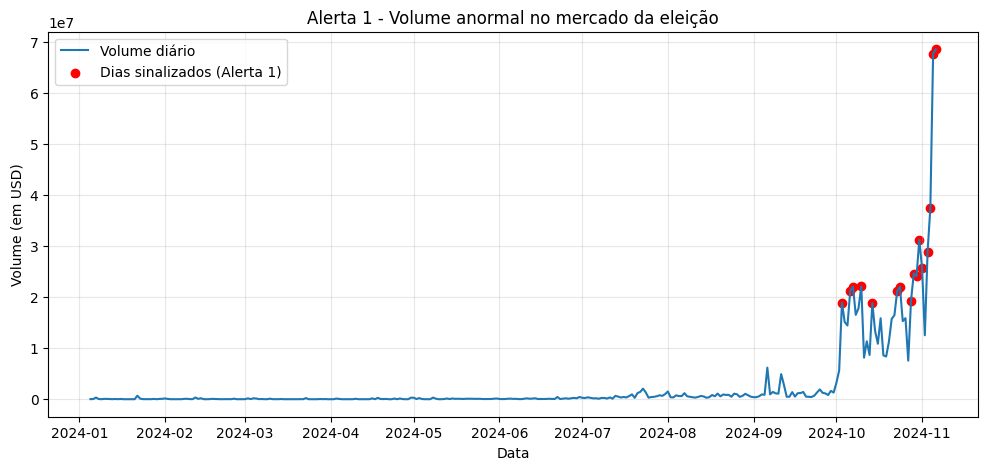

In [16]:
plt.figure(figsize=(12,5))
plt.plot(df["trade_date"], df["daily_usd_volume"], label="Volume diário")
plt.scatter(alerta_volume["trade_date"], alerta_volume["daily_usd_volume"],color="red", label="Dias sinalizados (Alerta 1)")
plt.title("Alerta 1 - Volume anormal no mercado da eleição")
plt.xlabel("Data")
plt.ylabel("Volume (em USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [17]:
# Métrica de assertividade — Alerta 1
# Janela de interesse: reta final da campanha até a eleição, período em que a imprensa
# relata o início da movimentação da "baleia" (a partir de out/2024)
inicio_janela = pd.Timestamp("2024-10-01")
fim_janela = pd.Timestamp("2024-11-06")

dentro_da_janela = alerta_volume["trade_date"].between(inicio_janela, fim_janela)
dias_no_periodo = (fim_janela - inicio_janela).days + 1

print(f"Dias sinalizados: {len(alerta_volume)}")
print(f"Sinalizados dentro da janela de interesse (01/10 a 06/11): {dentro_da_janela.sum()}")
print(f"Assertividade (precisão): {dentro_da_janela.mean():.1%}")
print(f"Cobertura: {dentro_da_janela.sum()} de {dias_no_periodo} dias da janela foram sinalizados ({dentro_da_janela.sum()/dias_no_periodo:.1%})")

Dias sinalizados: 16
Sinalizados dentro da janela de interesse (01/10 a 06/11): 16
Assertividade (precisão): 100.0%
Cobertura: 16 de 37 dias da janela foram sinalizados (43.2%)


Os 16 dias sinalizados pelo Alerta 1 caem, sem exceção, dentro da janela de interesse, onde nenhum dos ~9 meses anteriores do mercado disparou o alerta. Ou seja: 100% de assertividade em relação ao período relevante, cobrindo cerca de 43% dos dias dessa janela (os dias de pico mais extremos, não todos os dias do período).

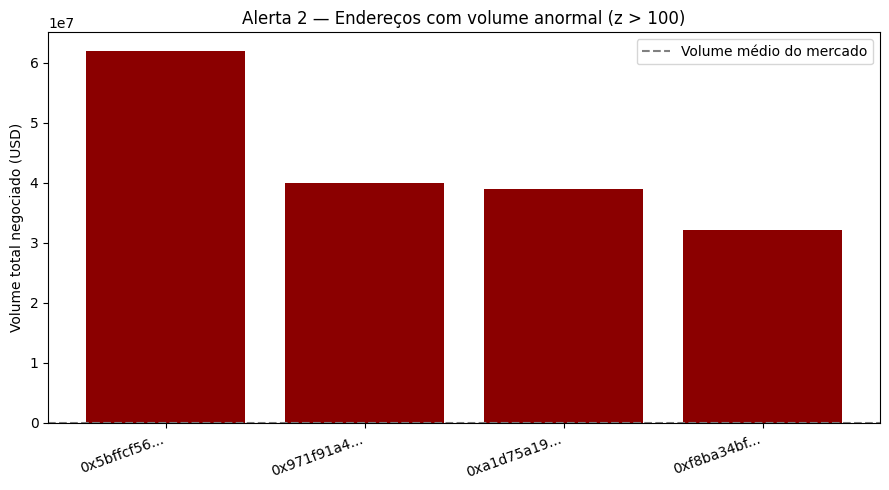

In [18]:
plt.figure(figsize=(9,5))
enderecos_curtos = [a[:10] + "..." for a in alerta_enderecos["address"]]
plt.bar(enderecos_curtos, alerta_enderecos["total_usd_volume"], color="darkred")
plt.axhline(alerta_enderecos["media_volume"].iloc[0], color="gray", linestyle="--",
            label="Volume médio do mercado")
plt.title("Alerta 2 — Endereços com volume anormal (z > 100)")
plt.ylabel("Volume total negociado (USD)")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Métrica de assertividade — Alerta 2
# "Movimento real relevante" = endereço cuja primeira operação no mercado começou
# na janela pré-eleição relatada pela imprensa (a partir de outubro de 2024)
inicio_acumulacao = pd.Timestamp("2024-10-01")

comecou_na_janela = alerta_enderecos["first_trade_date"] >= inicio_acumulacao

print(f"Endereços sinalizados: {len(alerta_enderecos)}")
print(f"Com primeira operação a partir de outubro/2024: {comecou_na_janela.sum()}")
print(f"Assertividade (perfil 'chegada tardia'): {comecou_na_janela.mean():.1%}")

Endereços sinalizados: 4
Com primeira operação a partir de outubro/2024: 1
Assertividade (perfil 'chegada tardia'): 25.0%


Só 1 dos 4 endereços sinalizados (25%) tem perfil de chegada tardia compatível com a reportagem, os demais são grandes traders presentes no mercado desde muito antes da reta final. Isso não invalida o alerta (ele está corretamente identificando os maiores outliers de volume absoluto do mercado), mas mostra que "volume anormalmente alto" e "chegada tardia e concentrada" são padrões parcialmente sobrepostos, não idênticos, reforçando que a hipótese inicial só pode ser parcialmente confirmada com esses dados.

## Conclusão

A análise do mercado `253591` mostrou um padrão de volume claramente concentrado na reta final da campanha, onde o Alerta 1 sinalizou 16 dias, todos dentro da janela de outubro-novembro de 2024, com os dois maiores z-scores (8,2 e 8,3) exatamente em 05 e 06/11, que foram os dias da apuração.

No nível de endereço, o Alerta 2 (z > 100) isolou 4 traders com volume ordens de magnitude acima da média do mercado. A investigação qualitativa de um endereço específico (`0xe9ad918c...`, Queries C e D) mostrou um caso concreto de aposta direcional concentrada, com cerca de US$25,8 milhões negociados entre 05 e 06/11, sempre do mesmo lado ("Yes"), compatível com o comportamento relatado pela imprensa sobre o "Trump Whale". 